In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from flax import nnx

import jaxpm
from jaxpm import hpm, camels, training, plotting, diagnostics, objectives
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.splines import NeuralSplineFourierFilterNNX
from jaxpm.nn import MLP, ConditionedCNN

print(jax.default_backend())

/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


gpu


# configuration

In [3]:
parts_per_dim = 128
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3

# CAMELS

In [4]:
CODE = "SIMBA"
# CODE = "ASTRID"
# CODE = "IllustrisTNG"

train_dict = camels.load_CV_snapshots(
    "CV_0",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=None,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE=CODE,
)

Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=128,mesh=128.h5


In [5]:
cosmo = train_dict["cosmo"]
scales = train_dict["scales"]
solve_ode = training.get_ode_solver(mesh_per_dim, cosmo)
solve_ode = jax.jit(solve_ode, static_argnames=("nt", "training"))

# Model

### checkpoint

In [6]:
d_hidden = 16
n_hidden = 6
checkpoint_file = "/global/u2/a/athomsen/flatiron/JaxPM/dev/apps/training/sweeps/128_cnn_v1/laced-sweep-21/checkpoint.jx"

In [7]:
# d_hidden = 16
# n_hidden = 8
# checkpoint_file = "/global/u2/a/athomsen/flatiron/JaxPM/dev/apps/training/sweeps/128_cnn_v1/royal-sweep-8/checkpoint.jx"

In [8]:
# d_hidden = 8
# n_hidden = 2
# checkpoint_file = "/global/u2/a/athomsen/flatiron/JaxPM/dev/apps/training/sweeps/128_cnn_v1/swept-sweep-6/checkpoint.jx"

In [9]:
# d_hidden = 16
# n_hidden = 2
# checkpoint_file = "/global/u2/a/athomsen/flatiron/JaxPM/dev/apps/training/sweeps/128_cnn_v1/vague-sweep-12/checkpoint.jx"

In [10]:
# https://wandb.ai/eth-cosmo/JaxHPM/runs/n9b9w87p?nw=nwuserarnethomsen

# d_hidden = 16
# n_hidden = 8
# checkpoint_file = "/global/u2/a/athomsen/flatiron/JaxPM/dev/apps/training/sweeps/128_cnn_v1/royal-sweep-8/checkpoint.jx"

### init

In [11]:
pressure_model = ConditionedCNN(
    d_in=4,
    d_out=1,
    d_hidden=d_hidden,
    n_hidden=n_hidden,
    kernel_size=(3, 3, 3),
    rngs=nnx.Rngs(0),
    norm_type="layer",
    activation=jax.nn.swish,
    use_residual=True,
)

pressure_model.load(checkpoint_file)

Checkpoint loaded from /global/u2/a/athomsen/flatiron/JaxPM/dev/apps/training/sweeps/128_cnn_v1/laced-sweep-21/checkpoint.jx


/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


# testing

In [12]:
@jax.jit
def get_cls(pos):
    rho = cic_paint(jnp.zeros(mesh_shape), pos)
    delta = rho / rho.mean() - 1

    k, cls = objectives.power_spectrum(delta)

    return k, cls

@jax.jit
def get_cross(pos_1, pos_2):
    rho_1 = cic_paint(jnp.zeros(mesh_shape), pos_1)
    delta_1 = rho_1 / rho_1.mean() - 1

    rho_2 = cic_paint(jnp.zeros(mesh_shape), pos_2)
    delta_2 = rho_2 / rho_2.mean() - 1

    k, cross = objectives.cross_correlation(delta_1, delta_2)

    return k, cross


In [17]:
cv_dir = "/pscratch/sd/a/athomsen/flatiron/CAMELS/Sims/SIMBA/CV"
i0 = 0
i1 = -1

all_ref_cls = []
all_res_cls = []
all_res_cross = []
for i in tqdm(range(3)):
    sim_file = os.path.join(cv_dir, f"CV_{i}", f"parts={parts_per_dim},mesh={mesh_per_dim}.h5")

    with h5py.File(sim_file) as f:
        i_snap = (i0, i1)
        
        scales = f["scales"][:]
        dm_poss = f["dm_poss"][i_snap, ...]
        dm_vels = f["dm_vels"][i_snap, ...]
        gas_poss = f["gas_poss"][i_snap, ...]
        gas_vels = f["gas_vels"][i_snap, ...]

    y0 = (dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0])
    t0 = scales[i0]
    tsave = [scales[i1]]
    res = solve_ode(
        y0, 
        t0, 
        tsave, 
        gravity_model=None, 
        pressure_model=pressure_model, 
        training=False, 
        nt=1, 
        tstep=scales
    )

    ref_pos = gas_poss[1]
    res_pos = res[2]
    
    k, ref_cls = get_cls(ref_pos)
    _, res_cls = get_cls(res_pos)
    _, res_cross = get_cross(res_pos, ref_pos)

    
    all_ref_cls.append(ref_cls)
    all_res_cls.append(res_cls)
    all_res_cross.append(res_cross)

    # fig, ax = plt.subplots()
    # ax.plot(k, res_cross / jnp.sqrt(ref_cls * res_cls) - 1)
    # ax.set(xscale="log", yscale="linear")

    # fig, ax = plt.subplots()
    # ax.plot(k, ref_cls)
    # ax.plot(k, res_cls, linestyle=":")
    # ax.set(xscale="log", yscale="log")

all_ref_cls = jnp.stack(all_ref_cls)
all_res_cls = jnp.stack(all_res_cls)
all_res_cross = jnp.stack(all_res_cross)

100%|██████████| 3/3 [00:04<00:00,  1.57s/it]


In [26]:
mean_ref_cls = all_ref_cls.mean(axis=0)
std_ref_cls = all_ref_cls.std(axis=0)

mean_res_cls = all_res_cls.mean(axis=0)
std_res_cls = all_res_cls.std(axis=0)

rel_cls = all_res_cls / all_ref_cls - 1
mean_rel_cls= jnp.mean(rel_cls, axis=0)
std_rel_cls = jnp.std(rel_cls, axis=0)

rel_cross = all_res_cross / jnp.sqrt(all_res_cls * all_ref_cls)
mean_rel_cross= jnp.mean(rel_cross, axis=0)
std_rel_cross = jnp.std(rel_cross, axis=0)

[None, None]

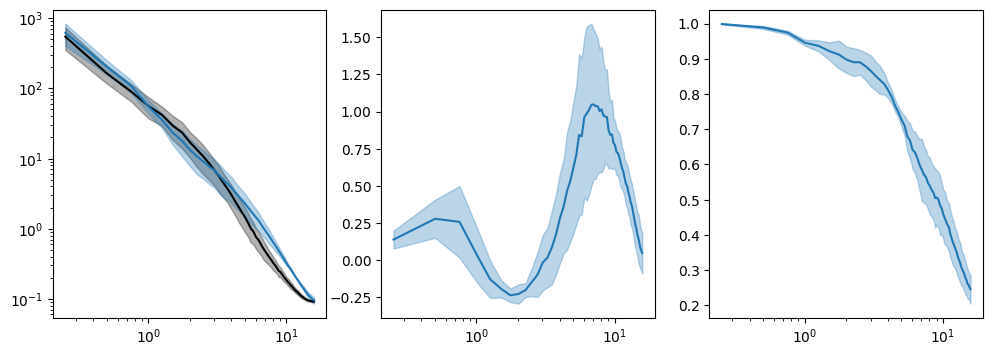

In [31]:
fig, ax = plt.subplots(ncols=3, figsize=(12,4), sharex=True)

# Cls
ax[0].plot(k, mean_ref_cls, color="k")
ax[0].fill_between(k, mean_ref_cls-std_ref_cls, mean_ref_cls+std_ref_cls, color="k", alpha=0.3)

ax[0].plot(k, mean_res_cls, color="tab:blue")
ax[0].fill_between(k, mean_res_cls-std_res_cls, mean_res_cls+std_res_cls, color="tab:blue", alpha=0.3)

# relative Cls
ax[1].plot(k, mean_rel_cls, color="tab:blue")
ax[1].fill_between(k, mean_rel_cls-std_rel_cls, mean_rel_cls+std_rel_cls, color="tab:blue", alpha=0.3)

# cross
ax[2].plot(k, mean_rel_cross, color="tab:blue")
ax[2].fill_between(k, mean_rel_cross-std_rel_cross, mean_rel_cross+std_rel_cross, color="tab:blue", alpha=0.3)

ax[0].set(xscale="log", yscale="log")
ax[1].set(xscale="log", yscale="linear")
ax[2].set(xscale="log", yscale="linear")

In [15]:
all_ref_cls[0].shape

(63,)

In [16]:
len(all_ref_cls)

3